In [1]:
import torch
torch.cuda.empty_cache()
import os
os.system("rm -rf ~/.cache/huggingface")

0

In [3]:
# Remove the corrupted or incomplete model download
!rm -rf ~/.cache/huggingface/hub/models--ContactDoctor--Bio-Medical-MultiModal-Llama-3-8B-V1

In [4]:
import torch
from PIL import Image
from huggingface_hub import snapshot_download
from transformers import AutoModel, AutoTokenizer, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

model = AutoModel.from_pretrained(
    "ContactDoctor/Bio-Medical-MultiModal-Llama-3-8B-V1",
    cache_dir="/scratch4/en520-lmorove1/en520-idev1/MLMA_Project/LLM_Code_Trials/Cache_Dir",
    quantization_config=bnb_config,
    torch_dtype=torch.float16,
    trust_remote_code=True,
    local_files_only=False
)

tokenizer = AutoTokenizer.from_pretrained(
    "ContactDoctor/Bio-Medical-MultiModal-Llama-3-8B-V1",
    trust_remote_code=True
)

/home/en520-idev1/.conda/envs/rfenv/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/en520-idev1/.conda/envs/rfenv/lib/python3.9/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
2025-04-07 16:59:57.626845: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-07 16:59:57.783753: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic lib

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/50.9k [00:00<?, ?B/s]

tokenization_minicpmv_fast.py:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/ContactDoctor/Bio-Medical-MultiModal-Llama-3-8B-V1:
- tokenization_minicpmv_fast.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/459 [00:00<?, ?B/s]

The segmentation model appears to predict the segmentation with high accuracy, as indicated by the close resemblance of the predicted images to the ground truth image. The images are axial MRI scans, which provide a detailed cross-sectional view of the brain. The abnormality visible in the images is a tumor, specifically a necrotic core within a larger mass. This type of abnormality suggests a malignant growth that may require aggressive treatment options such as surgery or radiation therapy, depending on the extent and location of the tumor.

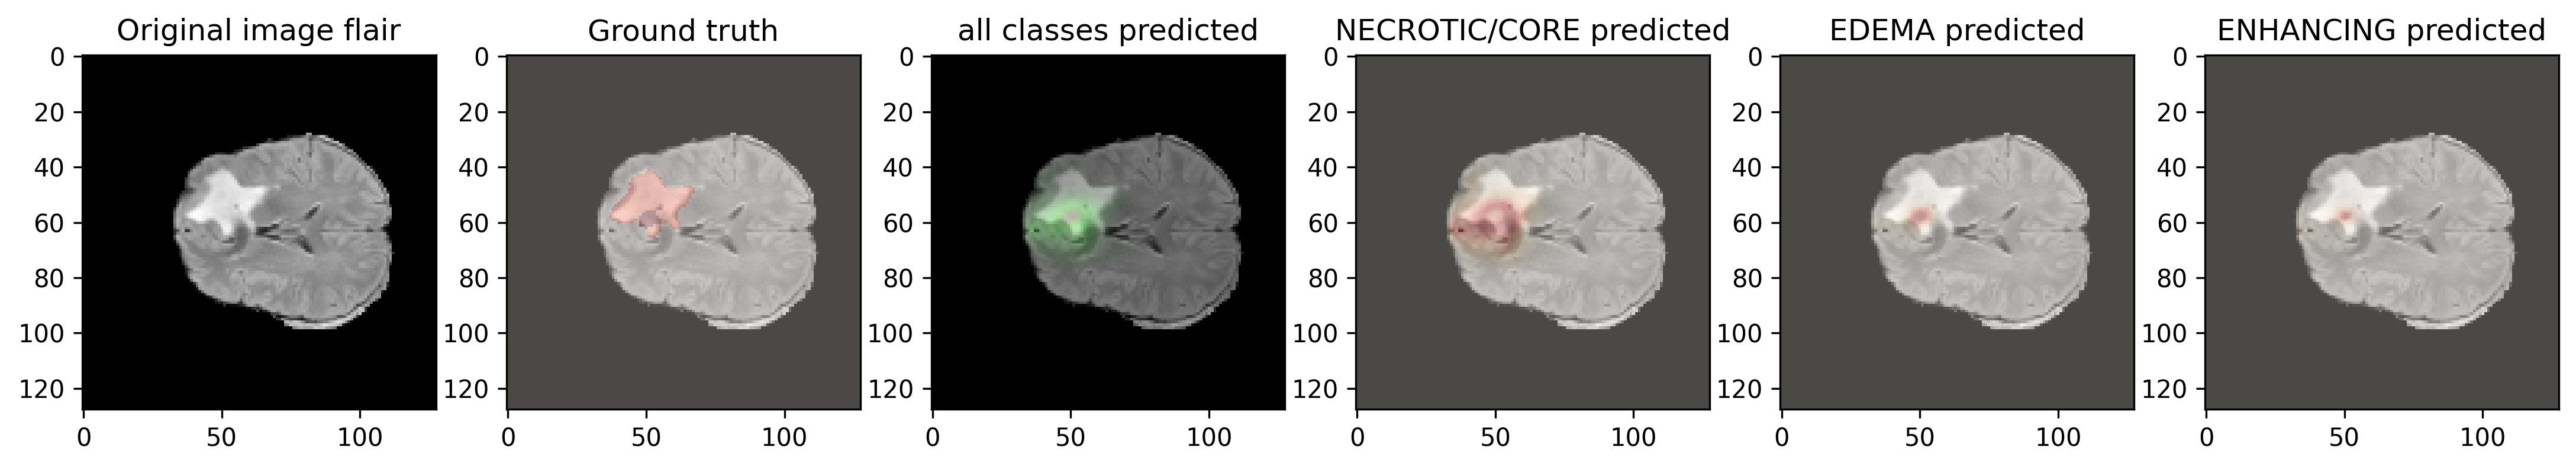

In [14]:
image = Image.open("/scratch4/en520-lmorove1/en520-idev1/MLMA_Project/UNet_Code_Trials/UNet_Kaggle_All4/flair_slice_sample.png").convert("RGB")

question = 'How well is the segmentation model able to predict the segmentation? Give a qualitative analysis. Also, give the type of MRI image, carefully inspecting the images, and give the organ, analysis, tumor analysis, and possible treatments based on the type of abnormality.'
msgs = [{'role': 'user', 'content': [image, question]}]

res = model.chat(image=image, msgs=msgs, tokenizer=tokenizer, temperature=0.5)

generated_text = ""
for new_text in res:
    generated_text += new_text
    print(new_text, flush=True, end='')
    
# Now, display the generated text in a neat wrapped text box:
from IPython.display import display, HTML

html_box = f"""
<div style="
    border: 1px solid #ccc;
    padding: 10px;
    background-color: #f9f9f9;
    border-radius: 5px;
    white-space: pre-wrap;
    word-wrap: break-word;
    font-family: monospace;
">
{generated_text}
</div>
"""
prompt_html = f"""
<div style="
    border: 1px solid #ccc;
    padding: 10px;
    background-color: #f9f9f9;
    border-radius: 5px;
    white-space: pre-wrap;
    word-wrap: break-word;
    font-family: monospace;
">
{question}
</div>
"""
display(HTML(prompt_html))
display(image)
display(HTML(html_box))